# XGBoost Regression Model — 15 Stocks

This notebook follows the same loop-based structure used in the LSTM model.

Instead of creating separate manual sections for each stock, this notebook processes all 15 stocks in one clean workflow:

1. Load all stock datasets
2. Clean dates, prices, and volume columns
3. Add market index context from S&P 500 and Nasdaq
4. Create time-series features
5. Train one XGBoost regression model per stock
6. Combine predictions for all 15 stocks
7. Evaluate using MAE, RMSE, directional accuracy, precision, recall, and F1 score
8. Rank stocks by predicted 7-day return
9. Simulate a simple top-ranked stock strategy
10. Save final output files

## 1. Import Libraries

This section imports the libraries needed for data cleaning, feature engineering, XGBoost modeling, evaluation, and visualization.

In [2]:
# Import libraries for data handling
import pandas as pd
import numpy as np
from pathlib import Path

# Import visualization library
import matplotlib.pyplot as plt

# Import XGBoost regression model
from xgboost import XGBRegressor

# Import regression and classification metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

## 2. Configuration

The notebook is expected to be saved inside `work/Models`.

The stock CSV files are located in the project-level `data` folder, so the path goes two levels up from the notebook location.

In [8]:
from pathlib import Path

# Project root folder on your local computer
PROJECT_ROOT = Path(
    r"C:\Users\POORVI NIDSOSHI\Desktop\Project-ML\group-project-algorithm-architects"
)

# Data folder inside the project
DATA_PATH = PROJECT_ROOT / "data"

# Check data path
print("DATA_PATH:", DATA_PATH)
print("Data path exists:", DATA_PATH.exists())
print("GSPC exists:", (DATA_PATH / "GSPC.csv").exists())
print("IXIC exists:", (DATA_PATH / "IXIC.csv").exists())
print("BA exists:", (DATA_PATH / "BA.csv").exists())

# Dictionary mapping stock tickers to CSV file names
stock_files = {
    "AAPL": "Apple.csv",
    "AMZN": "Amazon.csv",
    "GOOGL": "Google.csv",
    "MSFT": "MSFT.csv",
    "NVDA": "NVIDIA.csv",
    "BA": "BA.csv",
    "CVX": "CVX.csv",
    "GS": "GSach.csv",
    "JNJ": "JNJ.csv",
    "JPM": "JPM.csv",
    "META": "META.csv",
    "PFE": "PFE.csv",
    "TSLA": "TSLA.csv",
    "WMT": "WMT.csv",
    "XOM": "XOM.csv"
}

# Check number of stock datasets
print("Number of stock datasets:", len(stock_files))

# Check whether all files exist
missing_files = []

for ticker, file_name in stock_files.items():
    file_path = DATA_PATH / file_name

    if not file_path.exists():
        missing_files.append((ticker, file_name))

print("Missing files:", missing_files)

DATA_PATH: C:\Users\POORVI NIDSOSHI\Desktop\Project-ML\group-project-algorithm-architects\data
Data path exists: True
GSPC exists: True
IXIC exists: True
BA exists: True
Number of stock datasets: 15
Missing files: []


## 3. Helper Functions

These helper functions clean the data and create features.

The CSV files contain values such as `6,278,100`, so numeric columns are cleaned by removing commas before converting to numbers.

In [9]:
def clean_numeric_column(series):
    """
    Convert comma-formatted text numbers into numeric values.
    Example: "6,278,100" becomes 6278100.
    """
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )


def parse_date_column(series):
    """
    Convert date values into datetime format.
    The stock CSV files use formats like 2/27/2026.
    """
    parsed = pd.to_datetime(series, format="%m/%d/%Y", errors="coerce")
    if parsed.isna().mean() > 0.5:
        parsed = pd.to_datetime(series, errors="coerce")
    return parsed


def calculate_rsi(series, window=14):
    """
    Calculate Relative Strength Index (RSI).
    RSI is a momentum indicator used to identify strength of price movement.
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


def load_stock_csv(file_path):
    """
    Load one stock CSV file and clean column names.
    """
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.replace(' ', '', regex=False).str.strip()
    return df

## 4. Feature Engineering Function

The feature engineering function creates the same type of time-series features used in the earlier XGBoost work:

- lagged close prices
- daily, weekly, and monthly returns
- moving averages
- volatility
- volume changes
- RSI
- calendar features
- future 7-day return target

The target variable is `target_7d_return`.

In [10]:
def create_xgboost_features(df):
    """
    Create XGBoost features for one stock dataframe.
    """
    # Copy dataframe to avoid modifying original data
    df = df.copy()

    # Clean column names
    df.columns = df.columns.str.replace(' ', '', regex=False).str.strip()

    # Convert Date column
    df["Date"] = parse_date_column(df["Date"])

    # Convert numeric columns
    numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = clean_numeric_column(df[col])

    # Remove invalid Date or Close rows
    df = df.dropna(subset=["Date", "Close"]).reset_index(drop=True)

    # Sort oldest to newest because the original CSVs are often newest to oldest
    df = df.sort_values("Date").reset_index(drop=True)

    # Lagged close price features
    df["close_lag_1"] = df["Close"].shift(1)
    df["close_lag_7"] = df["Close"].shift(7)
    df["close_lag_30"] = df["Close"].shift(30)

    # Return features
    df["return_1d"] = df["Close"].pct_change(1)
    df["return_7d"] = df["Close"].pct_change(7)
    df["return_30d"] = df["Close"].pct_change(30)

    # Moving averages
    df["ma_7"] = df["Close"].rolling(window=7).mean()
    df["ma_30"] = df["Close"].rolling(window=30).mean()
    df["ma_200"] = df["Close"].rolling(window=200).mean()

    # Volatility features
    df["volatility_7"] = df["return_1d"].rolling(window=7).std()
    df["volatility_30"] = df["return_1d"].rolling(window=30).std()

    # Volume features
    df["volume_change_1d"] = df["Volume"].pct_change(1)
    df["volume_ma_7"] = df["Volume"].rolling(window=7).mean()
    df["volume_ma_30"] = df["Volume"].rolling(window=30).mean()
    df["volume_ratio_30"] = df["Volume"] / df["volume_ma_30"]

    # RSI feature
    df["rsi_14"] = calculate_rsi(df["Close"], window=14)

    # Calendar features
    df["weekday"] = df["Date"].dt.weekday
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter

    # Target: future 7-day return
    df["target_7d_return"] = df["Close"].shift(-7) / df["Close"] - 1

    # Direction target used later for classification-style evaluation
    df["target_direction"] = (df["target_7d_return"] > 0).astype(int)

    return df

## 5. Load Market Index Data

The model uses market context from:

- S&P 500 (`GSPC.csv`)
- Nasdaq (`IXIC.csv`)

These are converted into daily return features and merged with each stock by date.

In [11]:
# Load S&P 500 data
sp500_df = load_stock_csv(DATA_PATH / "GSPC.csv")
sp500_df["Date"] = parse_date_column(sp500_df["Date"])
sp500_df["Close"] = clean_numeric_column(sp500_df["Close"])
sp500_df = sp500_df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
sp500_df["sp500_return"] = sp500_df["Close"].pct_change()
sp500_df = sp500_df[["Date", "sp500_return"]]

# Load Nasdaq data
nasdaq_df = load_stock_csv(DATA_PATH / "IXIC.csv")
nasdaq_df["Date"] = parse_date_column(nasdaq_df["Date"])
nasdaq_df["Close"] = clean_numeric_column(nasdaq_df["Close"])
nasdaq_df = nasdaq_df.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
nasdaq_df["nasdaq_return"] = nasdaq_df["Close"].pct_change()
nasdaq_df = nasdaq_df[["Date", "nasdaq_return"]]

print("S&P 500 rows:", len(sp500_df))
print("Nasdaq rows:", len(nasdaq_df))
print("S&P 500 date range:", sp500_df["Date"].min(), "to", sp500_df["Date"].max())
print("Nasdaq date range:", nasdaq_df["Date"].min(), "to", nasdaq_df["Date"].max())

S&P 500 rows: 2805
Nasdaq rows: 2805
S&P 500 date range: 2015-01-02 00:00:00 to 2026-02-27 00:00:00
Nasdaq date range: 2015-01-02 00:00:00 to 2026-02-27 00:00:00


## 6. Train XGBoost Models for All 15 Stocks

This section follows the LSTM-style loop approach.

For each stock:

1. Load CSV file
2. Create features
3. Merge S&P 500 and Nasdaq returns
4. Split into train, validation, and test sets using time order
5. Train an XGBoost regressor
6. Predict future 7-day return
7. Store predictions and metrics

A separate XGBoost model is trained for each stock, but all predictions are combined into one final dataframe.

In [14]:
# Define feature columns used by XGBoost
feature_cols = [
    "close_lag_1",
    "close_lag_7",
    "close_lag_30",
    "return_1d",
    "return_7d",
    "return_30d",
    "ma_7",
    "ma_30",
    "ma_200",
    "volatility_7",
    "volatility_30",
    "volume_change_1d",
    "volume_ma_7",
    "volume_ma_30",
    "volume_ratio_30",
    "rsi_14",
    "sp500_return",
    "nasdaq_return",
    "weekday",
    "month",
    "quarter"
]

# Lists to store outputs
all_predictions = []
all_metrics = []
feature_importance_rows = []

# Loop through all 15 stocks
for ticker, file_name in stock_files.items():
    print(f"Processing {ticker}...")

    # Load stock data
    df = load_stock_csv(DATA_PATH / file_name)

    # Add stock ticker
    df["Stock"] = ticker

    # Create technical features
    df = create_xgboost_features(df)

    # Merge market index returns
    df = df.merge(sp500_df, on="Date", how="left")
    df = df.merge(nasdaq_df, on="Date", how="left")

    # Remove missing values created by feature engineering and market merges
    df = df.dropna(subset=feature_cols + ["target_7d_return"]).reset_index(drop=True)

    # Sort by date
    df = df.sort_values("Date").reset_index(drop=True)

    print("Rows after cleaning:", len(df))
    print("Date range:", df["Date"].min(), "to", df["Date"].max())

    # Skip if data is too small
    if len(df) < 100:
        print(f"Skipping {ticker}: not enough rows after cleaning.")
        continue

    # Time-based split
    train_df = df[df["Date"] < "2024-01-01"].copy()
    val_df = df[(df["Date"] >= "2024-01-01") & (df["Date"] < "2025-01-01")].copy()
    test_df = df[df["Date"] >= "2025-01-01"].copy()

    # Fallback split if fixed-date split creates an empty test set
    if len(train_df) == 0 or len(test_df) == 0:
        split_index = int(len(df) * 0.80)
        train_df = df.iloc[:split_index].copy()
        val_df = pd.DataFrame(columns=df.columns)
        test_df = df.iloc[split_index:].copy()

    # Separate features and target
    X_train = train_df[feature_cols]
    y_train = train_df["target_7d_return"]

    X_test = test_df[feature_cols]
    y_test = test_df["target_7d_return"]

    # Define XGBoost model
    model = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict test data
    predicted_returns = model.predict(X_test)

    # Create prediction dataframe
    pred_df = test_df[["Date", "Stock"]].copy()
    pred_df["Actual Return"] = y_test.values
    pred_df["Predicted Return"] = predicted_returns
    pred_df["Actual Direction"] = (pred_df["Actual Return"] > 0).astype(int)
    pred_df["Predicted Direction"] = (pred_df["Predicted Return"] > 0).astype(int)
    pred_df["Signal"] = np.where(pred_df["Predicted Return"] > 0, "Buy", "Avoid")

    # Store predictions
    all_predictions.append(pred_df)

    # Calculate regression metrics
    mae = mean_absolute_error(y_test, predicted_returns)
    rmse = np.sqrt(mean_squared_error(y_test, predicted_returns))

    # Calculate classification-style direction metrics
    y_true_direction = pred_df["Actual Direction"]
    y_pred_direction = pred_df["Predicted Direction"]

    accuracy = accuracy_score(y_true_direction, y_pred_direction)
    precision = precision_score(y_true_direction, y_pred_direction, zero_division=0)
    recall = recall_score(y_true_direction, y_pred_direction, zero_division=0)
    f1 = f1_score(y_true_direction, y_pred_direction, zero_division=0)

    # Store metrics
    all_metrics.append({
        "Stock": ticker,
        "Rows Used": len(df),
        "Train Rows": len(train_df),
        "Validation Rows": len(val_df),
        "Test Rows": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "Directional Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Store feature importances for this stock
    for feature, importance in zip(feature_cols, model.feature_importances_):
        feature_importance_rows.append({
            "Stock": ticker,
            "Feature": feature,
            "Importance": importance
        })

    print(f"{ticker} model trained successfully.")


# Combine all prediction dataframes
xgboost_predictions_df = pd.concat(all_predictions, ignore_index=True)

# Create metrics dataframe
xgboost_metrics_df = pd.DataFrame(all_metrics)

# Create feature importance dataframe
xgboost_feature_importance_df = pd.DataFrame(feature_importance_rows)

print("Final number of stocks:", xgboost_predictions_df["Stock"].nunique())
print("Stocks included:", sorted(xgboost_predictions_df["Stock"].unique()))

xgboost_predictions_df.head()

Processing AAPL...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
AAPL model trained successfully.
Processing AMZN...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
AMZN model trained successfully.
Processing GOOGL...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
GOOGL model trained successfully.
Processing MSFT...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
MSFT model trained successfully.
Processing NVDA...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
NVDA model trained successfully.
Processing BA...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
BA model trained successfully.
Processing CVX...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:00 to 2026-02-18 00:00:00
CVX model trained successfully.
Processing GS...
Rows after cleaning: 2599
Date range: 2015-10-16 00:00:0

,Date,Stock,Actual Return,Predicted Return,Actual Direction,Predicted Direction,Signal
0,2025-01-02,AAPL,-0.043346,-0.045059,0,0,Avoid
1,2025-01-03,AAPL,-0.022559,-0.040999,0,0,Avoid
2,2025-01-06,AAPL,-0.068327,-0.042966,0,0,Avoid
3,2025-01-07,AAPL,-0.050493,-0.025821,0,0,Avoid
4,2025-01-08,AAPL,-0.082653,-0.036029,0,0,Avoid


## 7. Model Performance Summary

This table shows model performance for each stock.

Regression metrics:
- MAE
- RMSE

Direction metrics:
- directional accuracy
- precision
- recall
- F1 score

In [15]:
# Sort metrics by F1 score from highest to lowest
xgboost_metrics_df = xgboost_metrics_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

xgboost_metrics_df

,Stock,Rows Used,Train Rows,Validation Rows,Test Rows,MAE,RMSE,Directional Accuracy,Precision,Recall,F1 Score
0,NVDA,2599,2065,252,282,0.086724,0.104784,0.592199,0.592199,1.000000,0.743875
1,PFE,2599,2065,252,282,0.047333,0.058050,0.503546,0.503650,0.971831,0.663462
2,CVX,2599,2065,252,282,0.032364,0.045139,0.574468,0.674074,0.544910,0.602649
3,MSFT,2599,2065,252,282,0.033446,0.046335,0.468085,0.485549,0.579310,0.528302
4,JNJ,2599,2065,252,282,0.031465,0.041114,0.485816,0.747573,0.392857,0.515050
5,XOM,2599,2065,252,282,0.041216,0.051135,0.478723,0.627660,0.345029,0.445283
6,BA,2599,2065,252,282,0.052859,0.067621,0.471631,0.583333,0.339394,0.429119
7,AAPL,2599,2065,252,282,0.055397,0.067173,0.517730,0.941176,0.105960,0.190476
8,TSLA,2599,2065,252,282,0.087671,0.108882,0.485816,0.500000,0.117241,0.189944
9,GOOGL,2599,2065,252,282,0.066919,0.079525,0.382979,0.666667,0.022727,0.043956


## 8. Overall XGBoost Evaluation

This section evaluates the combined predictions across all 15 stocks.

In [16]:
# Overall regression metrics
overall_mae = mean_absolute_error(
    xgboost_predictions_df["Actual Return"],
    xgboost_predictions_df["Predicted Return"]
)

overall_rmse = np.sqrt(mean_squared_error(
    xgboost_predictions_df["Actual Return"],
    xgboost_predictions_df["Predicted Return"]
))

# Overall classification-style metrics
overall_accuracy = accuracy_score(
    xgboost_predictions_df["Actual Direction"],
    xgboost_predictions_df["Predicted Direction"]
)

overall_precision = precision_score(
    xgboost_predictions_df["Actual Direction"],
    xgboost_predictions_df["Predicted Direction"],
    zero_division=0
)

overall_recall = recall_score(
    xgboost_predictions_df["Actual Direction"],
    xgboost_predictions_df["Predicted Direction"],
    zero_division=0
)

overall_f1 = f1_score(
    xgboost_predictions_df["Actual Direction"],
    xgboost_predictions_df["Predicted Direction"],
    zero_division=0
)

print("Overall XGBoost Performance")
print("MAE:", round(overall_mae, 4))
print("RMSE:", round(overall_rmse, 4))
print("Directional Accuracy:", round(overall_accuracy, 4))
print("Precision:", round(overall_precision, 4))
print("Recall:", round(overall_recall, 4))
print("F1 Score:", round(overall_f1, 4))

Overall XGBoost Performance
MAE: 0.0604
RMSE: 0.0766
Directional Accuracy: 0.4733
Precision: 0.5857
Recall: 0.293
F1 Score: 0.3906


## 9. Confusion Matrix

The XGBoost model predicts numerical 7-day return.

To evaluate direction, returns are converted into classes:

- 1 = positive return
- 0 = negative or zero return

In [17]:
# Create confusion matrix
cm = confusion_matrix(
    xgboost_predictions_df["Actual Direction"],
    xgboost_predictions_df["Predicted Direction"]
)

# Display as dataframe
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_df

,Predicted 0,Predicted 1
Actual 0,1288,505
Actual 1,1723,714


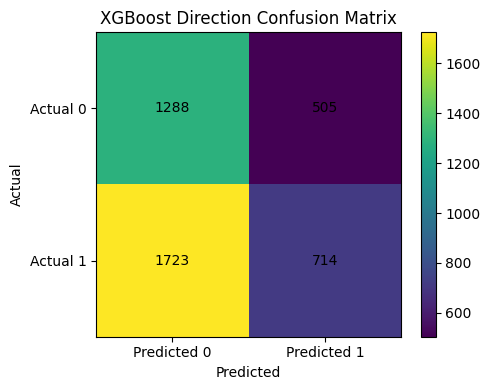

In [18]:
# Plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, aspect="auto")
plt.title("XGBoost Direction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.tight_layout()
plt.show()

## 10. Feature Importance

XGBoost provides feature importance values, which help identify which variables influenced the model most.

The chart below shows the average feature importance across all 15 stock-specific models.

In [19]:
# Average feature importance across all stocks
avg_feature_importance = (
    xgboost_feature_importance_df
    .groupby("Feature", as_index=False)["Importance"]
    .mean()
    .sort_values("Importance", ascending=False)
)

avg_feature_importance

,Feature,Importance
3,ma_200,0.075269
5,ma_7,0.071124
4,ma_30,0.068545
14,volatility_30,0.060561
10,return_30d,0.060454
8,quarter,0.058848
6,month,0.058114
17,volume_ma_30,0.057196
18,volume_ma_7,0.052894
15,volatility_7,0.047154


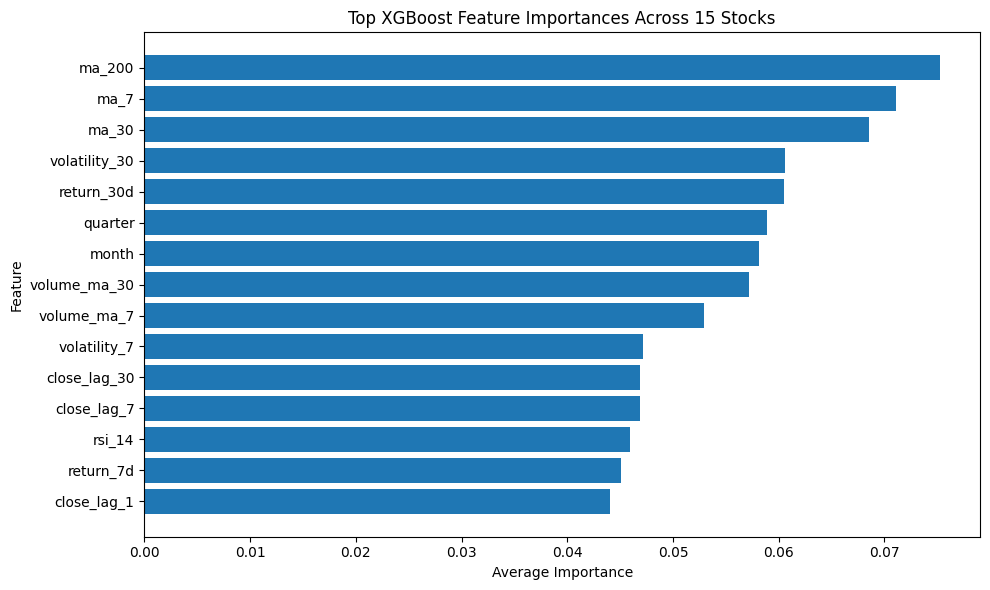

In [20]:
# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    avg_feature_importance["Feature"].head(15)[::-1],
    avg_feature_importance["Importance"].head(15)[::-1]
)

plt.title("Top XGBoost Feature Importances Across 15 Stocks")
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Predicted Return Distribution by Stock

This visualization compares predicted 7-day returns across the 15 stocks.

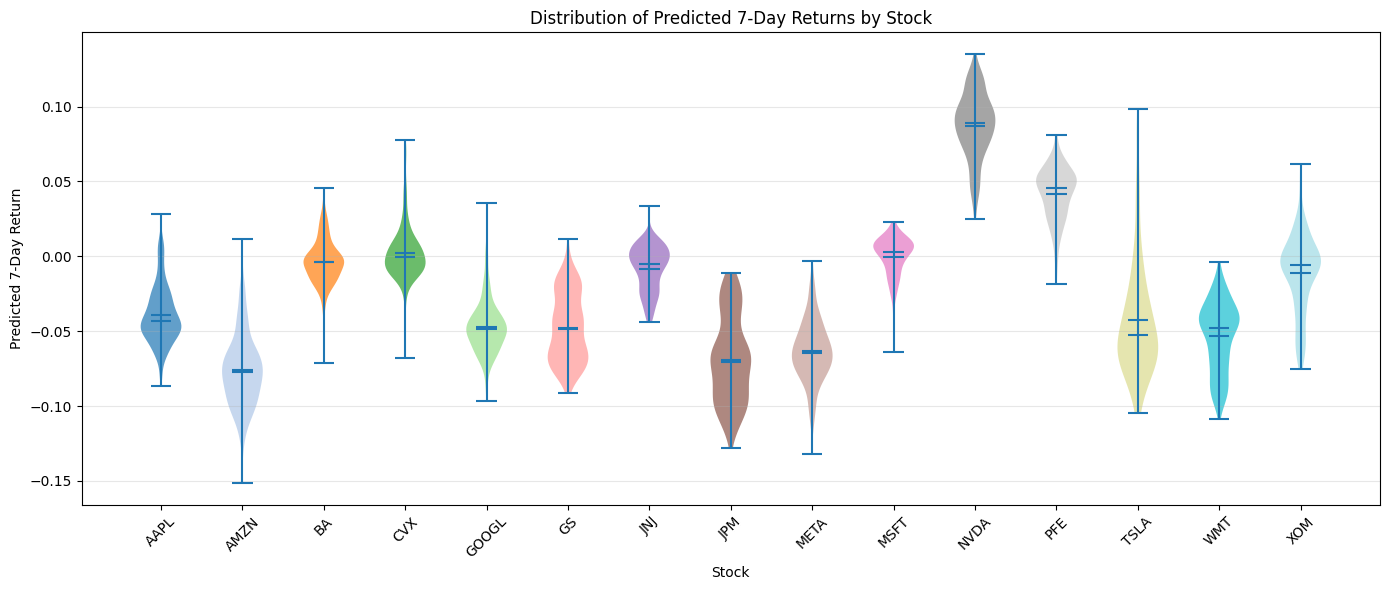

In [21]:
# Prepare data for violin plot
stocks = sorted(xgboost_predictions_df["Stock"].unique())
data_to_plot = [
    xgboost_predictions_df[xgboost_predictions_df["Stock"] == stock]["Predicted Return"].dropna()
    for stock in stocks
]

plt.figure(figsize=(14, 6))
violin = plt.violinplot(data_to_plot, showmeans=True, showmedians=True)

colors = plt.cm.tab20(np.linspace(0, 1, len(data_to_plot)))
for body, color in zip(violin["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.7)

plt.xticks(np.arange(1, len(stocks) + 1), stocks, rotation=45)
plt.title("Distribution of Predicted 7-Day Returns by Stock")
plt.xlabel("Stock")
plt.ylabel("Predicted 7-Day Return")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Weekly Stock Rankings

Stocks are ranked by predicted 7-day return for each date.

Rank 1 means the stock has the highest predicted return for that date.

In [22]:
# Rank stocks by predicted return for each date
xgboost_predictions_df["Rank"] = xgboost_predictions_df.groupby("Date")[
    "Predicted Return"
].rank(ascending=False, method="first")

# Sort by date and rank
xgboost_predictions_df = xgboost_predictions_df.sort_values(
    ["Date", "Rank"]
).reset_index(drop=True)

xgboost_predictions_df.head(15)

,Date,Stock,Actual Return,Predicted Return,Actual Direction,Predicted Direction,Signal,Rank
0,2025-01-02,NVDA,-0.047357,0.113695,0,1,Buy,1.0
1,2025-01-02,MSFT,-0.006952,0.010434,0,1,Buy,2.0
2,2025-01-02,CVX,0.069457,0.003010,1,1,Buy,3.0
3,2025-01-02,BA,-0.028219,0.002432,0,1,Buy,4.0
4,2025-01-02,JNJ,0.005069,-0.000133,1,0,Avoid,5.0
5,2025-01-02,PFE,-0.007516,-0.011087,0,0,Avoid,6.0
6,2025-01-02,TSLA,0.045033,-0.029654,1,0,Avoid,7.0
7,2025-01-02,XOM,0.022458,-0.042461,1,0,Avoid,8.0
8,2025-01-02,AAPL,-0.043346,-0.045059,0,0,Avoid,9.0
9,2025-01-02,GS,-0.005983,-0.054565,0,0,Avoid,10.0


## 13. Most Frequently Top-Ranked Stocks

This chart shows which stocks were most often ranked #1 by the XGBoost model.

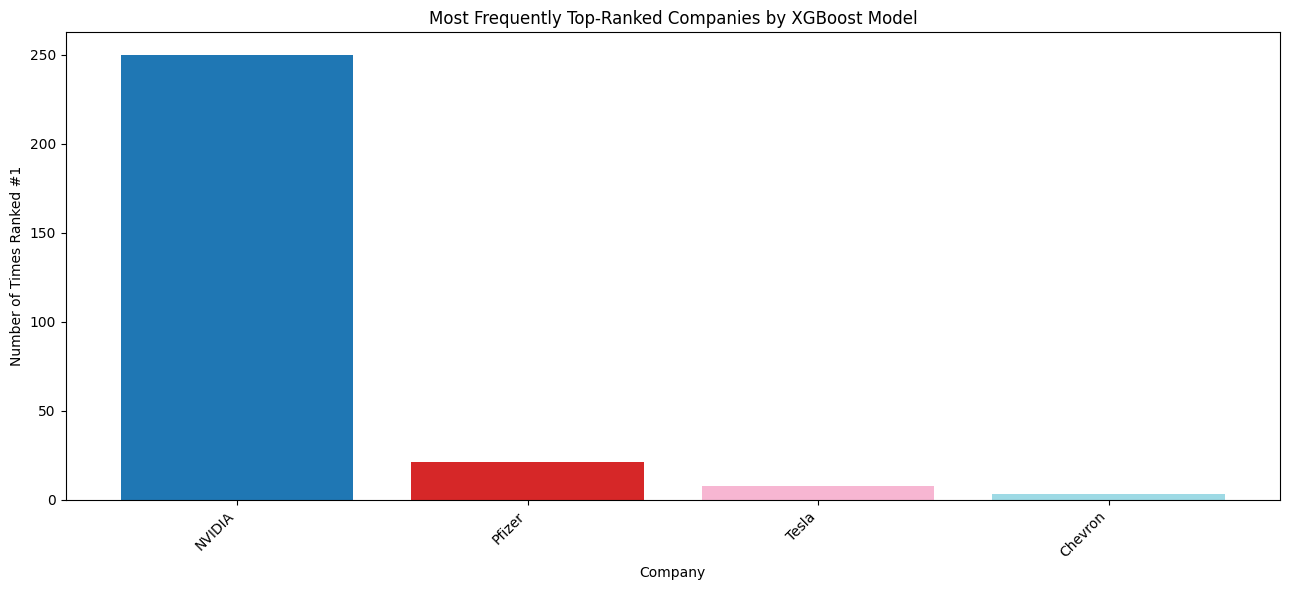

In [23]:
# Select rank 1 stock for each date
top_ranked_xgb = xgboost_predictions_df[
    xgboost_predictions_df["Rank"] == 1
].copy()

# Count top-ranked frequency
top_stock_counts = top_ranked_xgb["Stock"].value_counts()

# Company names for chart labels
company_names = {
    "AAPL": "Apple",
    "AMZN": "Amazon",
    "GOOGL": "Google",
    "MSFT": "Microsoft",
    "NVDA": "NVIDIA",
    "BA": "Boeing",
    "CVX": "Chevron",
    "GS": "Goldman Sachs",
    "JNJ": "Johnson & Johnson",
    "JPM": "JPMorgan Chase",
    "META": "Meta",
    "PFE": "Pfizer",
    "TSLA": "Tesla",
    "WMT": "Walmart",
    "XOM": "Exxon Mobil"
}

company_labels = [company_names.get(stock, stock) for stock in top_stock_counts.index]
colors = plt.cm.tab20(np.linspace(0, 1, len(top_stock_counts)))

plt.figure(figsize=(13, 6))
plt.bar(company_labels, top_stock_counts.values, color=colors)
plt.title("Most Frequently Top-Ranked Companies by XGBoost Model")
plt.xlabel("Company")
plt.ylabel("Number of Times Ranked #1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Investment Simulation

This simulation invests in the top-ranked stock for each date and updates the portfolio using the actual realized 7-day return.

The purpose is to test whether the XGBoost ranking output has practical investment value.

In [24]:
# Select top-ranked stock for each date
top_xgb_df = xgboost_predictions_df[
    xgboost_predictions_df["Rank"] == 1
].copy()

# Initial investment amount
initial_capital = 10000
capital = initial_capital

# Store portfolio values
portfolio_values = []

# Update portfolio using actual return of selected top-ranked stock
for actual_return in top_xgb_df["Actual Return"]:
    capital = capital * (1 + actual_return)
    portfolio_values.append(capital)

# Store results
top_xgb_df["Portfolio Value"] = portfolio_values
top_xgb_df["Profit/Loss"] = top_xgb_df["Portfolio Value"] - initial_capital

top_xgb_df.head()

,Date,Stock,Actual Return,Predicted Return,Actual Direction,Predicted Direction,Signal,Rank,Portfolio Value,Profit/Loss
0,2025-01-02,NVDA,-0.047357,0.113695,0,1,Buy,1.0,9526.426144,-473.573856
15,2025-01-03,NVDA,-0.056967,0.086853,0,1,Buy,1.0,8983.735709,-1016.264291
30,2025-01-06,NVDA,-0.106137,0.100329,0,1,Buy,1.0,8030.232073,-1969.767927
45,2025-01-07,NVDA,-0.017340,0.097577,0,1,Buy,1.0,7890.989430,-2109.010570
60,2025-01-08,NVDA,0.005139,0.117070,1,1,Buy,1.0,7931.539801,-2068.460199


In [25]:
# Calculate portfolio summary
final_value = top_xgb_df["Portfolio Value"].iloc[-1]
total_profit = final_value - initial_capital
total_return_pct = (final_value / initial_capital - 1) * 100

print("Initial Capital:", initial_capital)
print("Final Portfolio Value:", round(final_value, 2))
print("Total Profit/Loss:", round(total_profit, 2))
print("Total Return (%):", round(total_return_pct, 2))

Initial Capital: 10000
Final Portfolio Value: 125435.53
Total Profit/Loss: 115435.53
Total Return (%): 1154.36


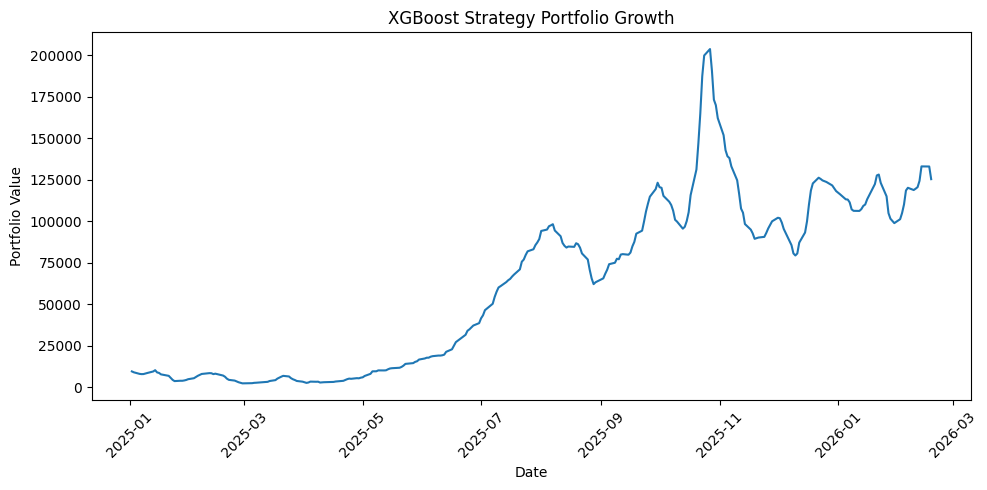

In [26]:
# Plot portfolio growth
plt.figure(figsize=(10, 5))
plt.plot(top_xgb_df["Date"], top_xgb_df["Portfolio Value"])
plt.title("XGBoost Strategy Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Save Final XGBoost Outputs

The final files are saved so they can be used in the final project comparison with Elastic Net Logistic, ARIMA, and LSTM.

In [27]:
# Save prediction and metrics outputs
xgboost_predictions_df.to_csv("xgboost_predictions_15_stocks.csv", index=False)
xgboost_metrics_df.to_csv("xgboost_metrics_15_stocks.csv", index=False)
xgboost_feature_importance_df.to_csv("xgboost_feature_importance_15_stocks.csv", index=False)
top_xgb_df.to_csv("xgboost_top_ranked_portfolio.csv", index=False)

print("Saved XGBoost output files successfully.")

Saved XGBoost output files successfully.


## XGBoost Model Methodology

### Objective
The objective of the XGBoost model is to predict each stock's next 7-day return and use those predictions for ranking and buy/avoid decisions.

### Data Preparation
- All 15 stock datasets were loaded from the project `data` folder.
- Date columns were converted into datetime format.
- Price and volume columns were converted from text to numeric format.
- S&P 500 and Nasdaq returns were merged as market context features.

### Feature Engineering
The model uses:
- lagged close prices
- return features
- moving averages
- volatility features
- volume features
- RSI
- calendar features
- market index returns

### Target Variable
The model predicts `target_7d_return`, which represents the next 7-day future return.

### Model Training
A separate XGBoost regressor was trained for each stock using the same loop-based process used in the LSTM model.

### Evaluation
The model was evaluated using:
- MAE
- RMSE
- directional accuracy
- precision
- recall
- F1 score

### Ranking and Investment Simulation
Stocks were ranked by predicted 7-day return for each date. The top-ranked stock was selected for a simple portfolio simulation to evaluate the practical value of the model's predictions.